# Stage 1: XRBench SA Size Sweep — Workload Characterization

Parses `outputs/stage1/<model>/sa<N>/scale_example_run_32x32_ws/COMPUTE_REPORT.csv`  
for all available models and SA sizes (16 / 32 / 64 / 128).  
Handles partial results — models not yet run are skipped automatically.

**Key metric:** `Overall Util %` — fraction of all SA PEs doing useful work, averaged over all cycles.  
A small layer on a 128×128 SA wastes most PEs → low utilization.  
**Latency metric:** sum of `Total Cycles (incl. prefetch)` across all layers.

In [23]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from pathlib import Path

plt.rcParams.update({
    'font.size': 11,
    'axes.titlesize': 12,
    'figure.dpi': 130,
})

RESULTS_ROOT = Path('outputs/xrbench')
SA_SIZES = [16, 32, 64, 128]

## 1. Load all COMPUTE_REPORTs into a master DataFrame

In [24]:
records = []
loaded_models = set()

# Each entry: (root dir, dataflow suffix). Earlier entries take priority.
SEARCH_ROOTS = [
    (Path('outputs/xrbench'),       'ws'),   # 7 models, weight-stationary
    (Path('outputs/xrbench_5_06'),  'os'),   # adds mobilellm_125m, output-stationary
]

for root, df_suffix in SEARCH_ROOTS:
    if not root.exists():
        continue
    for model_dir in sorted(root.iterdir()):
        if not model_dir.is_dir():
            continue
        model = model_dir.name
        if model in loaded_models:
            continue  # already loaded from a higher-priority root
        model_records = []
        for sa in SA_SIZES:
            run_subdir = f'scale_{sa}x{sa}_{df_suffix}'
            report = model_dir / f'sa{sa}' / run_subdir / 'COMPUTE_REPORT.csv'
            if not report.exists():
                continue
            df = pd.read_csv(report, skipinitialspace=True)
            df.columns = df.columns.str.strip()
            df = df.loc[:, df.columns != '']
            df['model'] = model
            df['sa_size'] = sa
            model_records.append(df)
        if model_records:
            records.extend(model_records)
            loaded_models.add(model)

if not records:
    raise RuntimeError('No COMPUTE_REPORT.csv files found')

raw = pd.concat(records, ignore_index=True)
raw.rename(columns={
    'LayerID': 'layer',
    'Total Cycles (incl. prefetch)': 'cycles_total',
    'Total Cycles': 'cycles_compute',
    'Stall Cycles': 'stall_cycles',
    'Overall Util %': 'util_overall',
    'Mapping Efficiency %': 'mapping_eff',
    'Compute Util %': 'util_compute',
}, inplace=True)

MODELS = sorted(raw['model'].unique())
print(f'Loaded {len(raw)} rows across {len(MODELS)} models: {MODELS}')
raw.head()

Loaded 2156 rows across 8 models: ['d2go', 'deit_small', 'emformer', 'eyecod', 'hand_pose', 'key_res15', 'mobilellm_125m', 'tcn']


,layer,cycles_total,cycles_compute,stall_cycles,util_overall,mapping_eff,util_compute,Unnamed: 7,model,sa_size
0,0,56598,51291,0,84.225303,84.375,84.174428,NaN,d2go,16
1,1,230103,225089,0,6.238532,6.250,6.234765,NaN,d2go,16
2,2,29928,25645,0,99.824527,100.000,99.762285,NaN,d2go,16
3,3,107890,102583,0,99.821608,100.000,99.762285,NaN,d2go,16
4,4,236323,232055,0,6.205425,6.250,6.190992,NaN,d2go,16


## 2. Summary table — total latency and mean utilization per (model, SA size)

In [25]:
summary = (
    raw.groupby(['model', 'sa_size'])
    .agg(
        total_cycles=('cycles_total', 'sum'),
        mean_util=('util_overall', 'mean'),
        min_util=('util_overall', 'min'),
        num_layers=('layer', 'count'),
    )
    .reset_index()
)

# speedup relative to SA=16 baseline
baseline = summary[summary['sa_size'] == 16][['model', 'total_cycles']].rename(
    columns={'total_cycles': 'cycles_sa16'})
summary = summary.merge(baseline, on='model')
summary['speedup'] = summary['cycles_sa16'] / summary['total_cycles']

pivot_util  = summary.pivot(index='model', columns='sa_size', values='mean_util').round(1)
pivot_speed = summary.pivot(index='model', columns='sa_size', values='speedup').round(2)

print('Mean Overall Util % by model and SA size:')
display(pivot_util)
print('\nSpeedup vs SA-16 baseline:')
display(pivot_speed)

Mean Overall Util % by model and SA size:


sa_size,16,32,64,128
model,,,,
d2go,57.8,41.4,27.9,16.5
deit_small,79.6,65.0,47.0,27.1
emformer,48.3,32.2,19.3,9.2
eyecod,74.4,65.7,55.3,31.9
hand_pose,58.4,48.7,38.2,18.2
key_res15,82.2,59.7,53.5,22.2
mobilellm_125m,88.7,80.9,70.5,51.9
tcn,57.6,38.4,23.8,4.9



Speedup vs SA-16 baseline:


sa_size,16,32,64,128
model,,,,
d2go,1.0,2.92,6.75,11.62
deit_small,1.0,3.25,9.14,20.74
emformer,1.0,2.65,6.24,13.39
eyecod,1.0,3.09,8.23,16.60
hand_pose,1.0,2.47,5.36,9.87
key_res15,1.0,2.89,9.58,14.93
mobilellm_125m,1.0,3.70,12.22,30.22
tcn,1.0,1.99,3.58,3.57


## 3. Utilization heatmap — all models × SA sizes

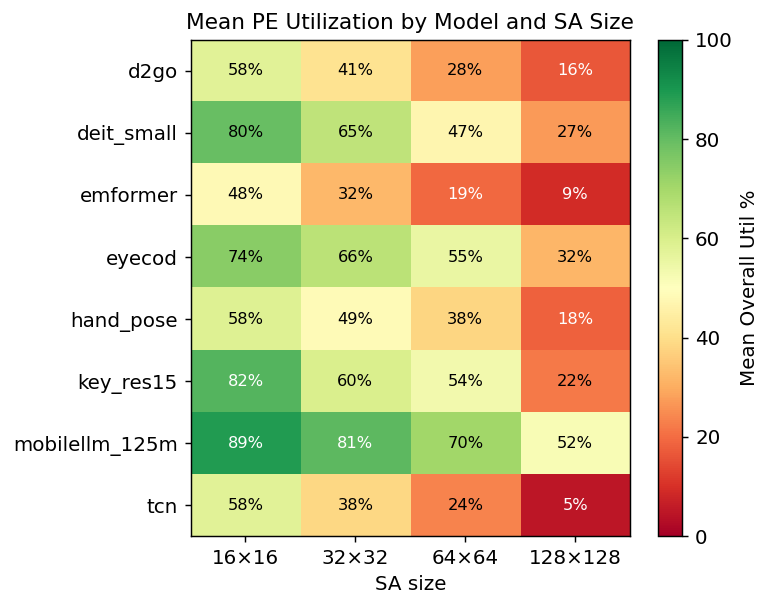

In [26]:
fig, ax = plt.subplots(figsize=(6, max(2.5, len(MODELS) * 0.6)))

data = pivot_util.values
im = ax.imshow(data, aspect='auto', cmap='RdYlGn', vmin=0, vmax=100)
plt.colorbar(im, ax=ax, label='Mean Overall Util %')

ax.set_xticks(range(len(pivot_util.columns)))
ax.set_xticklabels([f'{s}×{s}' for s in pivot_util.columns])
ax.set_yticks(range(len(MODELS)))
ax.set_yticklabels(pivot_util.index)
ax.set_xlabel('SA size')
ax.set_title('Mean PE Utilization by Model and SA Size')

for i in range(data.shape[0]):
    for j in range(data.shape[1]):
        if not np.isnan(data[i, j]):
            ax.text(j, i, f'{data[i,j]:.0f}%', ha='center', va='center', fontsize=9,
                    color='black' if 20 < data[i, j] < 80 else 'white')

plt.tight_layout()
plt.savefig('outputs/stage1/fig_util_heatmap.pdf', bbox_inches='tight')
plt.show()

## 4. Total latency bar chart — per model, bars = SA size

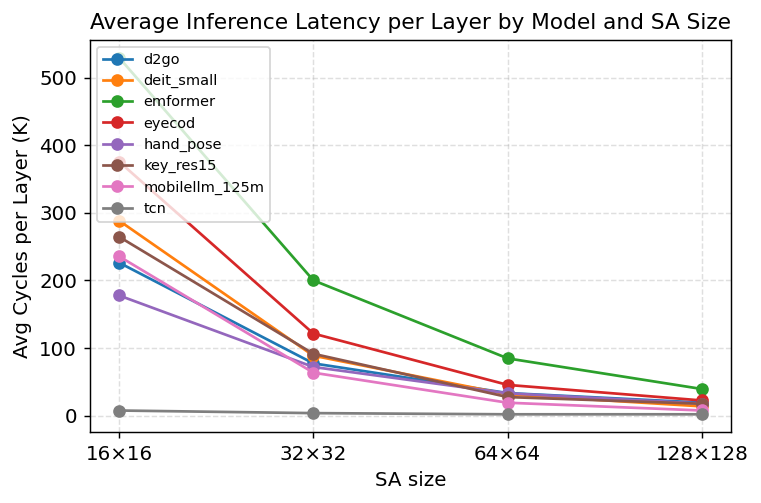

In [27]:
fig, ax = plt.subplots(figsize=(6, 4))

for m in MODELS:
    sub = summary[summary['model'] == m].sort_values('sa_size')
    avg_latency = sub['total_cycles'] / sub['num_layers'] / 1e3
    ax.plot(sub['sa_size'], avg_latency, marker='o', label=m)

ax.set_xscale('log', base=2)
ax.set_xticks(SA_SIZES)
ax.set_xticklabels([f'{s}×{s}' for s in SA_SIZES])
ax.set_xlabel('SA size')
ax.set_ylabel('Avg Cycles per Layer (K)')
ax.set_title('Average Inference Latency per Layer by Model and SA Size')
ax.legend(fontsize=8, loc='upper left')
ax.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig('outputs/stage1/fig_latency_lines.pdf', bbox_inches='tight')
plt.show()

## 5. Mean utilization vs SA size — line plot per model

Key hypothesis: small models (hand_pose, eyecod, key_res15) have steeply falling utilization  
as SA size grows, because their small tensors cannot fill a 128×128 array.

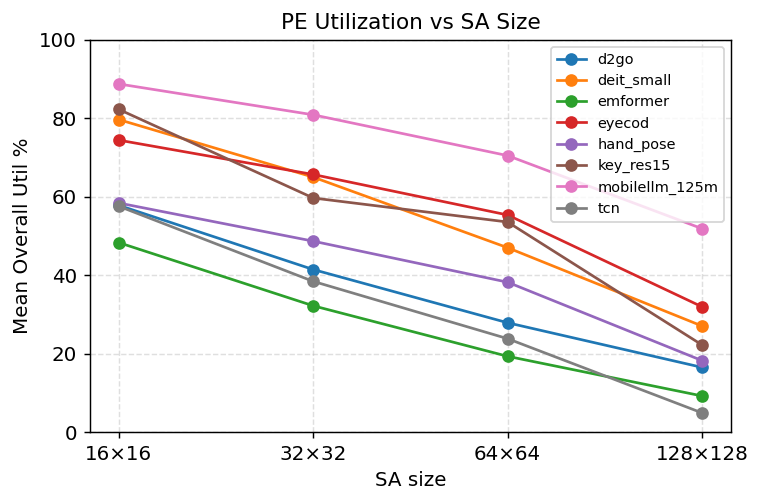

In [28]:
fig, ax = plt.subplots(figsize=(6, 4))

for m in MODELS:
    sub = summary[summary['model'] == m].sort_values('sa_size')
    ax.plot(sub['sa_size'], sub['mean_util'], marker='o', label=m)

ax.set_xscale('log', base=2)
ax.set_xticks(SA_SIZES)
ax.set_xticklabels([f'{s}×{s}' for s in SA_SIZES])
ax.set_ylim(0, 100)
ax.set_xlabel('SA size')
ax.set_ylabel('Mean Overall Util %')
ax.set_title('PE Utilization vs SA Size')
ax.legend(fontsize=8, loc='upper right')
ax.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig('outputs/stage1/fig_util_vs_sa.pdf', bbox_inches='tight')
plt.show()

## 6. Speedup vs SA-16 baseline — line plot per model

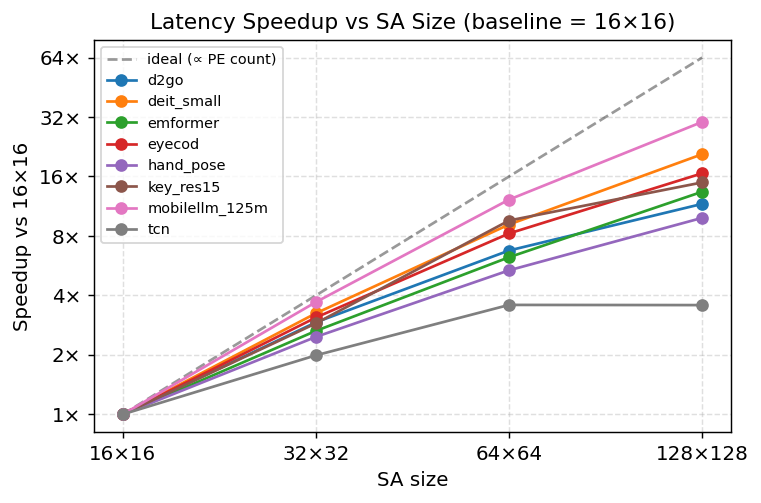

In [29]:
fig, ax = plt.subplots(figsize=(6, 4))

# ideal speedup for a linear SA (4× PEs → 4× throughput if fully utilized)
ideal_x = SA_SIZES
ideal_y = [s**2 / SA_SIZES[0]**2 for s in SA_SIZES]  # area-proportional ideal
ax.plot(ideal_x, ideal_y, 'k--', alpha=0.4, label='ideal (∝ PE count)')

for m in MODELS:
    sub = summary[summary['model'] == m].sort_values('sa_size')
    ax.plot(sub['sa_size'], sub['speedup'], marker='o', label=m)

ax.set_xscale('log', base=2)
ax.set_yscale('log', base=2)
ax.set_xticks(SA_SIZES)
ax.set_xticklabels([f'{s}×{s}' for s in SA_SIZES])
ax.set_yticks([1, 2, 4, 8, 16, 32, 64])
ax.set_yticklabels(['1×', '2×', '4×', '8×', '16×', '32×', '64×'])
ax.set_xlabel('SA size')
ax.set_ylabel('Speedup vs 16×16')
ax.set_title('Latency Speedup vs SA Size (baseline = 16×16)')
ax.legend(fontsize=8)
ax.grid(True, linestyle='--', alpha=0.4, which='both')

plt.tight_layout()
plt.savefig('outputs/stage1/fig_speedup.pdf', bbox_inches='tight')
plt.show()

## 7. Per-layer utilization deep-dive — sparse_to_dense (depth completion)

`sparse_to_dense` (ResNet encoder + decoder, 58 layers) is the best available substitute for MiDaS
because it has a clear **encoder-decoder arc**:
- **Encoder** (layers 0–52): spatial shrinks, channels grow — utilization *falls* as SA grows relative to feature map size
- **Decoder** (layers 53–57): spatial *expands* — utilization *recovers*

This non-monotonic arc directly motivates Stage 2/3: backbone layers need a larger SA;
decoder layers are efficiently served by a smaller one.
Falls back to `midas` if available (boundary = 52).

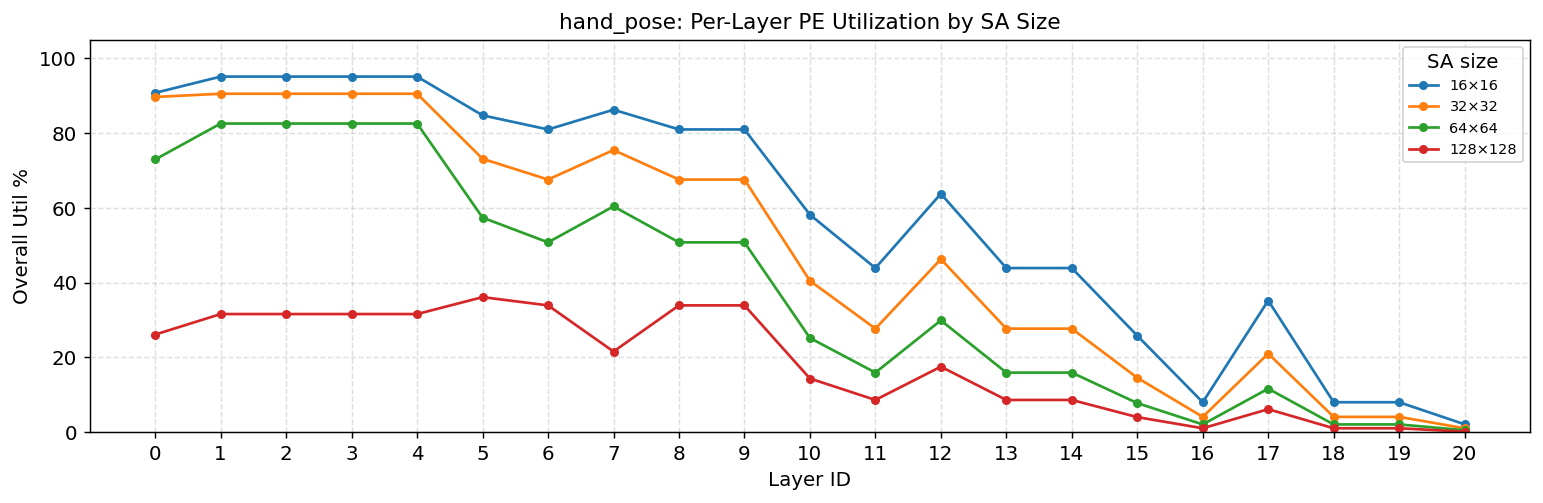

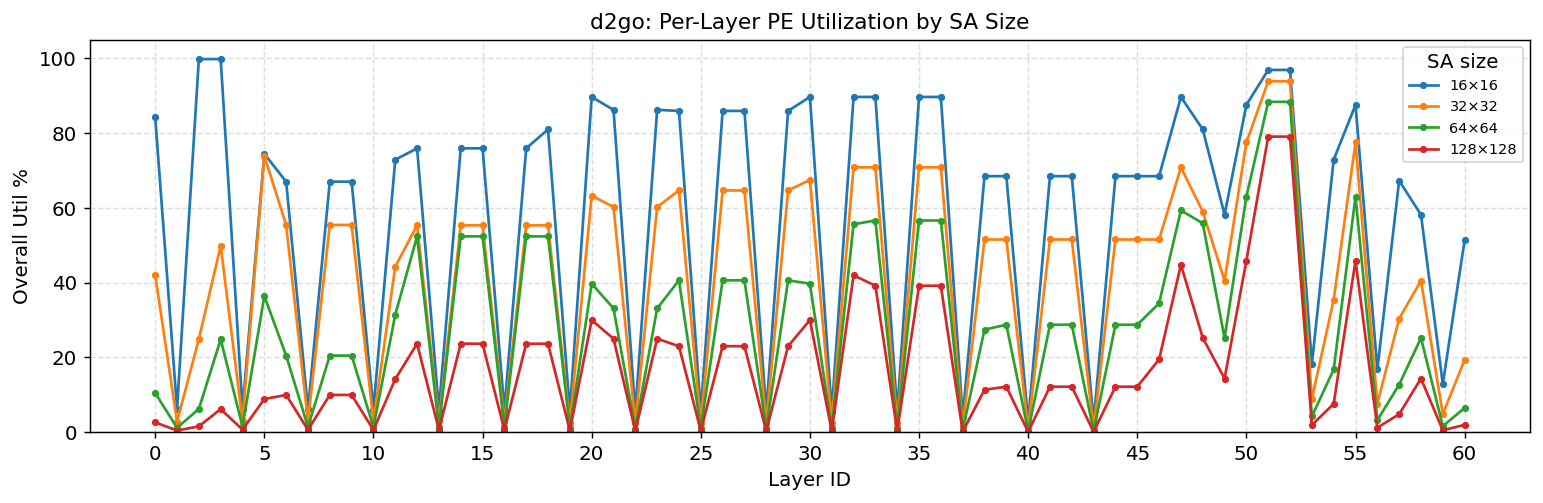

In [30]:
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

# --- Plot A: hand_pose per-layer utilization ---
FOCUS_MODEL_A = 'hand_pose'
fm_a = raw[raw['model'] == FOCUS_MODEL_A].copy()
layers_a = sorted(fm_a['layer'].unique())

fig, ax = plt.subplots(figsize=(12, 4))
for sa, color in zip(SA_SIZES, colors):
    sub = fm_a[fm_a['sa_size'] == sa].sort_values('layer')
    ax.plot(sub['layer'], sub['util_overall'], marker='o', ms=4,
            label=f'{sa}×{sa}', color=color)

ax.set_xticks(layers_a)
ax.set_xlabel('Layer ID')
ax.set_ylabel('Overall Util %')
ax.set_title(f'{FOCUS_MODEL_A}: Per-Layer PE Utilization by SA Size')
ax.set_ylim(0, 105)
ax.legend(title='SA size', fontsize=8)
ax.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig(f'outputs/stage1/fig_{FOCUS_MODEL_A}_layer_util.pdf', bbox_inches='tight')
plt.show()

# --- Plot B: d2go per-layer utilization (shows a clear low→high gradient across 61 layers) ---
FOCUS_MODEL_B = 'd2go'
fm_b = raw[raw['model'] == FOCUS_MODEL_B].copy()
layers_b = sorted(fm_b['layer'].unique())

fig, ax = plt.subplots(figsize=(12, 4))
for sa, color in zip(SA_SIZES, colors):
    sub = fm_b[fm_b['sa_size'] == sa].sort_values('layer')
    ax.plot(sub['layer'], sub['util_overall'], marker='o', ms=3,
            label=f'{sa}×{sa}', color=color)

ax.set_xticks(layers_b[::5])
ax.set_xlabel('Layer ID')
ax.set_ylabel('Overall Util %')
ax.set_title(f'{FOCUS_MODEL_B}: Per-Layer PE Utilization by SA Size')
ax.set_ylim(0, 105)
ax.legend(title='SA size', fontsize=8)
ax.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig(f'outputs/stage1/fig_{FOCUS_MODEL_B}_layer_util.pdf', bbox_inches='tight')
plt.show()

## 8. Utilization heatmap — sparse_to_dense (layers × SA sizes)

Row = layer ID, column = SA size. The encoder-decoder arc appears as a red/yellow band
in the deep encoder (small spatial, large channels) transitioning to green in the
decoder (layers 53–57, expanding spatial). The dashed white line marks the boundary.

In [31]:
fm_pivot = fm.pivot(index='layer', columns='sa_size', values='util_overall')

fig, ax = plt.subplots(figsize=(4, max(5, len(fm_pivot) * 0.18)))
im = ax.imshow(fm_pivot.values, aspect='auto', cmap='RdYlGn', vmin=0, vmax=100)
plt.colorbar(im, ax=ax, label='Overall Util %')

ax.set_xticks(range(len(fm_pivot.columns)))
ax.set_xticklabels([f'{s}×{s}' for s in fm_pivot.columns])
ax.set_yticks(range(len(fm_pivot.index)))
ax.set_yticklabels(fm_pivot.index, fontsize=7)
ax.set_xlabel('SA size')
ax.set_ylabel('Layer ID')
ax.set_title(f'{FOCUS_MODEL}: Layer × SA Utilization Heatmap')

# annotate encoder/decoder boundary on heatmap
if boundary is not None:
    ax.axhline(boundary - 0.5, color='white', linewidth=1.5, linestyle='--')
    ax.text(len(fm_pivot.columns) - 0.45, boundary - 1.2, 'decoder ↓',
            color='white', fontsize=7, ha='right')

plt.tight_layout()
plt.savefig(f'outputs/stage1/fig_{FOCUS_MODEL}_layer_heatmap.pdf', bbox_inches='tight')
plt.show()

NameError: name 'fm' is not defined

## 9. Bottleneck analysis — bottom-k layers by utilization (SA=128)

Identifies the layers that will hurt most on a large array.  
These are the layers a future scheduler should preferentially route to a smaller SA.

In [ ]:
SA_FOCUS = 128
K = 5

bottlenecks = (
    raw[raw['sa_size'] == SA_FOCUS]
    .sort_values('util_overall')
    [['model', 'layer', 'util_overall', 'mapping_eff', 'cycles_total']]
    .head(K * len(MODELS))
)
print(f'Bottom-{K} per model on SA {SA_FOCUS}×{SA_FOCUS}:')
display(
    bottlenecks.groupby('model')
    .apply(lambda g: g.nsmallest(K, 'util_overall'))
    .reset_index(drop=True)
    .round(2)
)

Bottom-5 per model on SA 128×128:


/tmp/ipykernel_185935/1753223694.py:13: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.nsmallest(K, 'util_overall'))


,model,layer,util_overall,mapping_eff,cycles_total
0,d2go,40,0.07,0.78,81782
1,d2go,43,0.07,0.78,81782
2,d2go,37,0.14,0.78,64345
3,d2go,22,0.34,0.73,13773
4,d2go,34,0.35,0.77,37155
5,eyecod,20,0.00,1.56,1662
6,hand_pose,20,0.13,49.22,4807
7,hand_pose,18,1.04,100.00,58922
8,hand_pose,16,1.04,100.00,58922
9,hand_pose,19,1.04,100.00,58922


## 10. DRAM bandwidth demand — load BANDWIDTH_REPORTs

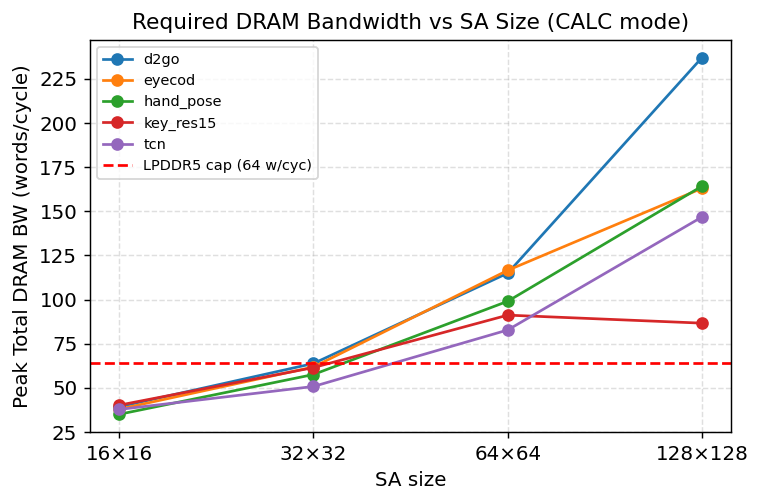

In [ ]:
bw_records = []

for model_dir in sorted(RESULTS_ROOT.iterdir()):
    if not model_dir.is_dir():
        continue
    model = model_dir.name
    for sa in SA_SIZES:
        report = model_dir / f'sa{sa}' / RUN_SUBDIR / 'BANDWIDTH_REPORT.csv'
        if not report.exists():
            continue
        df = pd.read_csv(report, skipinitialspace=True)
        df.columns = df.columns.str.strip()
        df = df.loc[:, df.columns != '']
        df['model'] = model
        df['sa_size'] = sa
        bw_records.append(df)

bw = pd.concat(bw_records, ignore_index=True)
bw.rename(columns={
    'LayerID': 'layer',
    'Avg IFMAP DRAM BW': 'bw_ifmap_dram',
    'Avg FILTER DRAM BW': 'bw_filter_dram',
    'Avg OFMAP DRAM BW': 'bw_ofmap_dram',
}, inplace=True)

bw['bw_total_dram'] = bw['bw_ifmap_dram'] + bw['bw_filter_dram'] + bw['bw_ofmap_dram']

bw_summary = (
    bw.groupby(['model', 'sa_size'])
    .agg(peak_dram_bw=('bw_total_dram', 'max'), mean_dram_bw=('bw_total_dram', 'mean'))
    .reset_index()
)

# LPDDR5 at 500 MHz ≈ 64 words/cycle capacity line
DRAM_CAP = 64

fig, ax = plt.subplots(figsize=(6, 4))
for m in MODELS:
    sub = bw_summary[bw_summary['model'] == m].sort_values('sa_size')
    ax.plot(sub['sa_size'], sub['peak_dram_bw'], marker='o', label=m)
ax.axhline(DRAM_CAP, color='red', linestyle='--', label=f'LPDDR5 cap ({DRAM_CAP} w/cyc)')
ax.set_xscale('log', base=2)
ax.set_xticks(SA_SIZES)
ax.set_xticklabels([f'{s}×{s}' for s in SA_SIZES])
ax.set_xlabel('SA size')
ax.set_ylabel('Peak Total DRAM BW (words/cycle)')
ax.set_title('Required DRAM Bandwidth vs SA Size (CALC mode)')
ax.legend(fontsize=8)
ax.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig('outputs/stage1/fig_dram_bw.pdf', bbox_inches='tight')
plt.show()

---
## Summary of figures generated

| File | What it shows |
|------|---------------|
| `fig_util_heatmap.pdf` | Mean utilization heatmap: all models × SA sizes |
| `fig_latency_bars.pdf` | Total cycles per model, grouped by SA size |
| `fig_util_vs_sa.pdf` | Utilization vs SA size line plot per model |
| `fig_speedup.pdf` | Speedup vs SA-16 baseline (log-log, vs ideal) |
| `fig_midas_layer_util.pdf` | Per-layer utilization for MiDaS — encoder-decoder arc with boundary annotation |
| `fig_midas_layer_heatmap.pdf` | Layer × SA size heatmap for MiDaS — shows utilization recovery in decoder |
| `fig_dram_bw.pdf` | Required DRAM bandwidth vs SA size |

**Why MiDaS for plots 7 & 8:** It is the only model with an encoder-decoder arc that produces
a non-monotonic per-layer utilization profile. The backbone (shrinking spatial) degrades
utilization as SA size grows; the decoder (expanding spatial, fixed 256ch) partially recovers it.
This directly motivates heterogeneous SA assignment in Stage 3.

**Stage 2 inputs (after full sweep):**
- Optimal SA size per model (from `fig_util_vs_sa`)
- DRAM-bandwidth-limited models (from `fig_dram_bw`) — candidates for USER mode analysis